In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import plotly.express as px

In [ ]:
url = "https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/main/social_media_engagement_5000.csv"

df = pd.read_csv(url)

df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [ ]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [6]:
df['posted_at'] = pd.to_datetime(df['posted_at'], format='%d-%m-%Y')

In [16]:
likes_array = np.array(df['likes'].dropna())

print("Maximum likes:", np.max(likes_array))
print("Minimum likes:", np.min(likes_array))
print("Average likes:", np.mean(likes_array))

Maximum likes: 19998.0
Minimum likes: 10.0
Average likes: 10107.043711340206


In [17]:
df.isnull().sum()

,0
user_id,0
age,150
gender,150
country,0
post_id,0
post_type,0
post_category,0
likes,150
comments,150
shares,150


In [18]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
age,150
gender,150
likes,150
comments,150
shares,150
sentiment,150


In [19]:
df['age'] = df['age'].fillna(df['age'].median())

In [20]:
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

In [21]:
df['likes'] = df['likes'].fillna(df['likes'].median())


In [22]:
df['comments'] = df['comments'].fillna(df['comments'].median())

In [23]:
df['shares'] = df['shares'].fillna(df['shares'].median())

In [24]:
df['sentiment'] = df['sentiment'].fillna(df['sentiment'].mode()[0])

In [25]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
post_id,0
post_type,0
post_category,0
likes,0
comments,0
shares,0


In [28]:
df.duplicated().sum()

np.int64(0)

In [31]:
df = df.drop_duplicates()

df

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [32]:
df['gender'] = df['gender'].str.strip().str.lower()
df['country'] = df['country'].str.strip().str.lower()
df['post_type'] = df['post_type'].str.strip().str.lower()
df['post_category'] = df['post_category'].str.strip().str.lower()
df['device_type'] = df['device_type'].str.strip().str.lower()
df['sentiment'] = df['sentiment'].str.strip().str.lower()

In [33]:
print(df['gender'].unique())
print(df['post_type'].unique())
print(df['post_category'].unique())
print(df['device_type'].unique())
print(df['sentiment'].unique())

['female' 'male' 'other']
['image' 'reel' 'text' 'video']
['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']
['mobile' 'tablet' 'desktop']
['negative' 'positive' 'neutral']


In [38]:
df = df[(df['likes'] >= 0) & (df['comments'] >= 0) & (df['shares'] >= 0)]



,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,female,brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,male,brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,female,uk,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,other,france,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,other,uk,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,59500,44.0,male,australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,other,uae,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,female,usa,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,female,germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518


In [42]:
df['hashtag_count'] = df['hashtags'].fillna('').str.split().str.len()

df[['hashtags', 'hashtag_count']]

,hashtags,hashtag_count
0,#foodie #travel #love,3
1,#fitness,1
2,#foodie,1
3,#music #foodie #fun,3
4,#travel,1
...,...,...
4995,#travel #fun,2
4996,#foodie #reels,2
4997,#lifestyle #tech,2
4998,#reels #love #fitness,3


In [45]:
df['sentiment'] = df['sentiment'].str.strip().str.lower()

df['sentiment'].unique()

array(['negative', 'positive', 'neutral'], dtype=object)

In [46]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
0,25795,43.0,female,brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.190862,3
1,10860,33.0,male,brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.201493,1
2,86820,32.0,female,uk,109864,text,food,4862.0,344.0,955.0,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.137345,1
3,64886,51.0,other,france,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.106195,3
4,16265,34.0,other,uk,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.777372,1


In [47]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count
4995,59500,44.0,male,australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,2022-06-25,646147,False,mobile,positive,#travel #fun,0.466761,2
4996,22100,38.0,other,uae,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,2022-11-18,584603,False,desktop,negative,#foodie #reels,0.621155,2
4997,67021,63.0,female,usa,273595,text,travel,13487.0,1497.0,167.0,7466,23680,2023-04-06,483550,False,desktop,positive,#lifestyle #tech,0.679688,2
4998,29800,13.0,female,germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,2022-05-16,183295,False,tablet,positive,#reels #love #fitness,0.223518,3
4999,73400,54.0,other,japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,2023-03-04,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527,3


In [48]:
df.shape

(5000, 20)

In [49]:
df.columns

Index(['user_id', 'age', 'gender', 'country', 'post_id', 'post_type',
       'post_category', 'likes', 'comments', 'shares', 'watch_time_sec',
       'impression_count', 'posted_at', 'follower_count', 'is_verified',
       'device_type', 'sentiment', 'hashtags', 'engagement_rate',
       'hashtag_count'],
      dtype='object')

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               5000 non-null   float64       
 2   gender            5000 non-null   object        
 3   country           5000 non-null   object        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   object        
 6   post_category     5000 non-null   object        
 7   likes             5000 non-null   float64       
 8   comments          5000 non-null   float64       
 9   shares            5000 non-null   float64       
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [51]:
df.dtypes

,0
user_id,int64
age,float64
gender,object
country,object
post_id,int64
post_type,object
post_category,object
likes,float64
comments,float64
shares,float64


In [52]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.440400,548042.909000,10106.997400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964356,1.998600
min,10055.000000,13.000000,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.006363,1.000000
25%,32309.500000,26.000000,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.145781,1.000000
50%,54374.500000,38.000000,548077.500000,10105.500000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.253896,2.000000
75%,77180.500000,51.000000,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.504794,3.000000
max,99963.000000,64.000000,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.504348,3.000000
std,26090.370121,14.687151,260646.957267,5702.293017,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.318029,0.812853


In [53]:
print(df['gender'].value_counts())
print(df['post_type'].value_counts())
print(df['post_category'].value_counts())
print(df['country'].value_counts())
print(df['sentiment'].value_counts())

gender
male      1849
other     1581
female    1570
Name: count, dtype: int64
post_type
reel     1283
image    1247
text     1245
video    1225
Name: count, dtype: int64
post_category
fitness      675
tech         665
music        635
education    631
lifestyle    607
travel       600
fashion      594
food         593
Name: count, dtype: int64
country
india        535
canada       513
brazil       504
uae          503
usa          501
france       496
uk           493
australia    493
germany      490
japan        472
Name: count, dtype: int64
sentiment
positive    2513
neutral     1527
negative     960
Name: count, dtype: int64


In [54]:
print(df['gender'].unique())
print(df['post_type'].unique())
print(df['post_category'].unique())
print(df['country'].unique())
print(df['sentiment'].unique())

['female' 'male' 'other']
['image' 'reel' 'text' 'video']
['fitness' 'food' 'tech' 'travel' 'fashion' 'lifestyle' 'education'
 'music']
['brazil' 'uk' 'france' 'canada' 'japan' 'australia' 'india' 'uae'
 'germany' 'usa']
['negative' 'positive' 'neutral']


In [55]:
print("Gender:", df['gender'].nunique())
print("Post Type:", df['post_type'].nunique())
print("Post Category:", df['post_category'].nunique())
print("Country:", df['country'].nunique())
print("Sentiment:", df['sentiment'].nunique())

Gender: 3
Post Type: 4
Post Category: 8
Country: 10
Sentiment: 3


In [56]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

correlation_matrix

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,follower_count,engagement_rate,hashtag_count
user_id,1.000000,-0.006688,0.020051,0.025811,-0.033395,0.013763,-0.016847,0.015326,0.010124,-0.004282,-0.013692
age,-0.006688,1.000000,-0.013153,-0.036322,-0.007284,0.013871,0.005542,0.013322,-0.024894,0.008039,0.007173
post_id,0.020051,-0.013153,1.000000,0.014526,-0.010540,0.001846,0.018374,-0.007709,-0.002844,0.010139,0.007344
likes,0.025811,-0.036322,0.014526,1.000000,-0.018421,0.004712,0.008710,0.007952,-0.022982,0.093520,-0.002190
comments,-0.033395,-0.007284,-0.010540,-0.018421,1.000000,0.006142,-0.016351,-0.009395,-0.011733,0.000051,-0.015230
shares,0.013763,0.013871,0.001846,0.004712,0.006142,1.000000,0.014658,-0.005204,-0.010783,0.021724,0.013379
watch_time_sec,-0.016847,0.005542,0.018374,0.008710,-0.016351,0.014658,1.000000,-0.004335,0.002761,-0.001148,-0.023301
impression_count,0.015326,0.013322,-0.007709,0.007952,-0.009395,-0.005204,-0.004335,1.000000,-0.015513,-0.232226,-0.002714
follower_count,0.010124,-0.024894,-0.002844,-0.022982,-0.011733,-0.010783,0.002761,-0.015513,1.000000,0.002292,0.008802
engagement_rate,-0.004282,0.008039,0.010139,0.093520,0.000051,0.021724,-0.001148,-0.232226,0.002292,1.000000,0.005319


In [57]:
df.groupby('post_type')['likes'].mean()

,likes
post_type,
image,10104.865277
reel,10037.802416
text,10100.148193
video,10188.600000


In [58]:
df.groupby('country')['impression_count'].mean()

,impression_count
country,
australia,48346.383367
brazil,49193.174603
canada,48703.150097
france,51727.673387
germany,48605.406122
india,52462.386916
japan,49616.135593
uae,48928.413519
uk,51119.393509


In [62]:
df['engagement_score'] = df['likes'] + df['comments'] + df['shares']

df[['likes', 'comments', 'shares', 'engagement_score']]

,likes,comments,shares,engagement_score
0,7011.0,354.0,1157.0,8522.0
1,11750.0,2606.0,1807.0,16163.0
2,4862.0,344.0,955.0,6161.0
3,5350.0,1083.0,1049.0,7482.0
4,12682.0,2735.0,1300.0,16717.0
...,...,...,...,...
4995,16210.0,2013.0,1837.0,20060.0
4996,16924.0,2734.0,1583.0,21241.0
4997,13487.0,1497.0,167.0,15151.0
4998,16894.0,1289.0,1713.0,19896.0


In [63]:
df['log_likes'] = np.log1p(df['likes'])

df[['likes', 'log_likes']]

,likes,log_likes
0,7011.0,8.855378
1,11750.0,9.371694
2,4862.0,8.489411
3,5350.0,8.585039
4,12682.0,9.448018
...,...,...
4995,16210.0,9.693445
4996,16924.0,9.736547
4997,13487.0,9.509556
4998,16894.0,9.734773


In [64]:
df.groupby('post_type')['engagement_score'].mean()

,engagement_score
post_type,
image,12649.390537
reel,12524.031567
text,12613.243775
video,12664.594286


In [65]:
df.groupby('country')['engagement_score'].mean()

,engagement_score
country,
australia,12809.621704
brazil,12385.983135
canada,12605.894737
france,12903.384073
germany,12635.664286
india,12492.701869
japan,12578.648305
uae,12757.777336
uk,12384.374239


In [66]:
df.groupby('sentiment')['engagement_score'].mean()

,engagement_score
sentiment,
negative,12731.498958
neutral,12448.163720
positive,12665.799443


In [67]:
columns = ['likes', 'comments', 'shares', 'watch_time_sec',
           'engagement_rate', 'follower_count']

for col in columns:
    print("\n", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])


 likes
Mean: 10106.9974
Median: 10105.5
Mode: 10105.5

 comments
Mean: 1502.0398
Median: 1497.0
Mode: 1497.0

 shares
Mean: 1002.9106
Median: 1012.0
Mode: 1012.0

 watch_time_sec
Mean: 4014.5032
Median: 4034.5
Mode: 916

 engagement_rate
Mean: 0.9643560291583999
Median: 0.2538959065
Mode: 0.006362909

 follower_count
Mean: 393698.2248
Median: 388982.0
Mode: 497502


In [68]:
for col in columns:
    print("\n", col)
    print("Standard Deviation:", df[col].std())
    print("Variance:", df[col].var())


 likes
Standard Deviation: 5702.293017183876
Variance: 32516145.653823998

 comments
Standard Deviation: 856.3933120458967
Variance: 733409.5049169405

 shares
Standard Deviation: 570.8551999758862
Variance: 325875.65933950903

 watch_time_sec
Standard Deviation: 2308.096459042085
Variance: 5327309.26424261

 engagement_rate
Standard Deviation: 5.318029222661535
Variance: 28.281434813082043

 follower_count
Standard Deviation: 230927.88453461014
Variance: 53327687855.63023


In [69]:
for col in columns:
    print("\n", col)
    print("25th Percentile:", df[col].quantile(0.25))
    print("50th Percentile:", df[col].quantile(0.50))
    print("75th Percentile:", df[col].quantile(0.75))


 likes
25th Percentile: 5235.0
50th Percentile: 10105.5
75th Percentile: 14959.0

 comments
25th Percentile: 792.0
50th Percentile: 1497.0
75th Percentile: 2235.25

 shares
25th Percentile: 511.0
50th Percentile: 1012.0
75th Percentile: 1483.0

 watch_time_sec
25th Percentile: 2017.75
50th Percentile: 4034.5
75th Percentile: 6020.25

 engagement_rate
25th Percentile: 0.14578108750000002
50th Percentile: 0.2538959065
75th Percentile: 0.504793702

 follower_count
25th Percentile: 194480.0
50th Percentile: 388982.0
75th Percentile: 589744.25


In [70]:
for col in columns:
    print("\n", col)
    print("Skewness:", df[col].skew())
    print("Kurtosis:", df[col].kurt())


 likes
Skewness: -0.006893616532184278
Kurtosis: -1.1499923609078424

 comments
Skewness: 0.0038017289479831415
Kurtosis: -1.1443748352968992

 shares
Skewness: -0.014653583910311461
Kurtosis: -1.1468565626589917

 watch_time_sec
Skewness: -0.018196273193231846
Kurtosis: -1.195651797070188

 engagement_rate
Skewness: 18.781270878869154
Kurtosis: 482.9917386319569

 follower_count
Skewness: 0.04111777394961326
Kurtosis: -1.1894740478821386


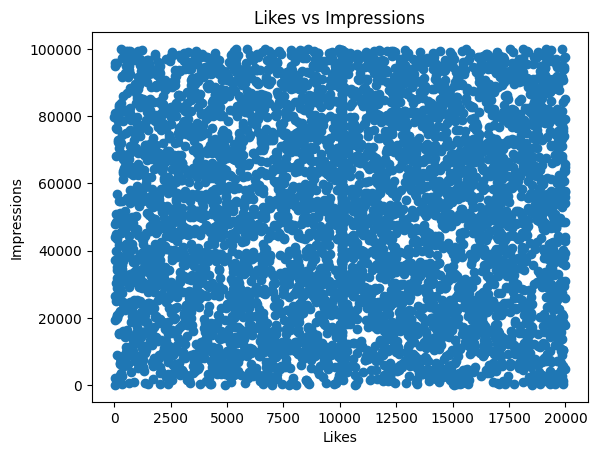

In [73]:
import matplotlib.pyplot as plt
plt.scatter(df['likes'], df['impression_count'])
plt.xlabel('Likes')
plt.ylabel('Impressions')
plt.title('Likes vs Impressions')
plt.show()

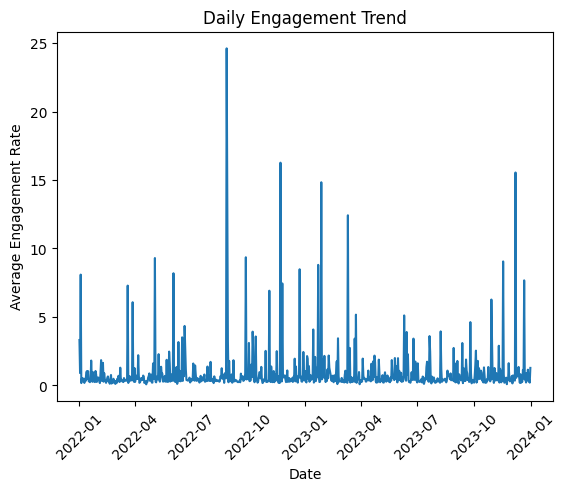

In [76]:
daily_engagement = df.groupby(df['posted_at'].dt.date)['engagement_rate'].mean()
plt.plot(daily_engagement.index, daily_engagement.values)
plt.xlabel('Date')
plt.ylabel('Average Engagement Rate')
plt.title('Daily Engagement Trend')
plt.xticks(rotation=45)
plt.show()

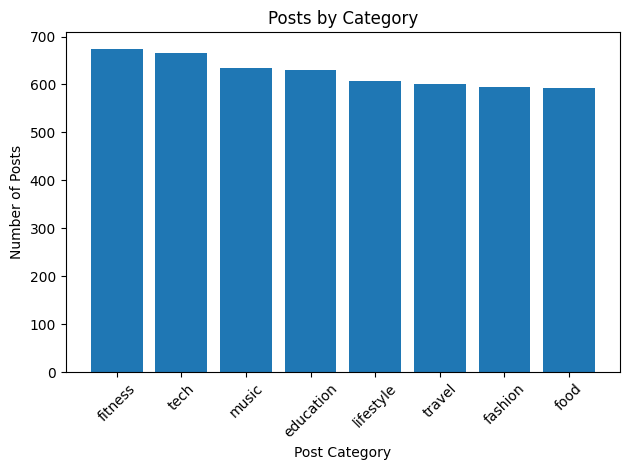

In [77]:
category_counts = df['post_category'].value_counts()
plt.bar(category_counts.index, category_counts.values)
plt.xlabel('Post Category')
plt.ylabel('Number of Posts')
plt.title('Posts by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

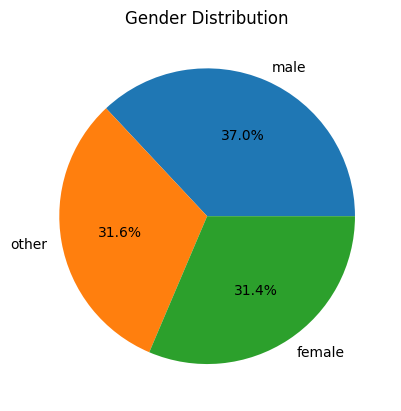

In [78]:
gender_counts = df['gender'].value_counts()
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%')
plt.title('Gender Distribution')
plt.show()

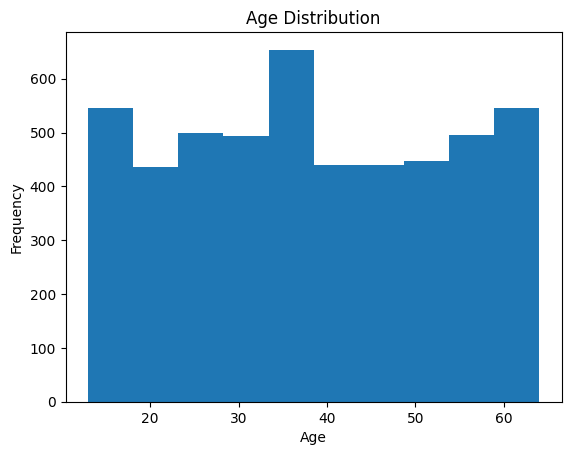

In [79]:
plt.hist(df['age'], bins=10)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

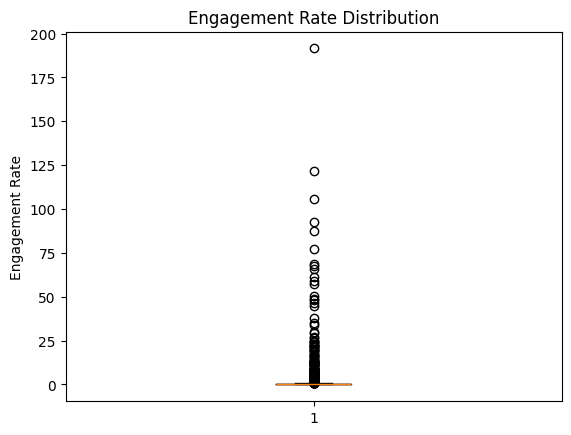

In [80]:
plt.boxplot(df['engagement_rate'])
plt.ylabel('Engagement Rate')
plt.title('Engagement Rate Distribution')
plt.show()

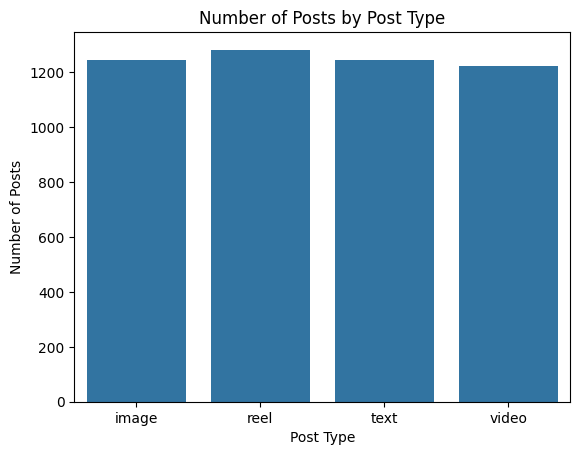

In [81]:
sns.countplot(data=df, x='post_type')
plt.xlabel('Post Type')
plt.ylabel('Number of Posts')
plt.title('Number of Posts by Post Type')
plt.show()

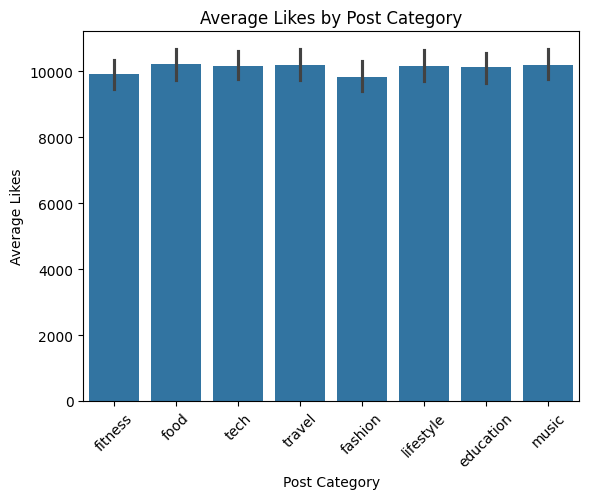

In [83]:
sns.barplot(data=df, x='post_category', y='likes')
plt.xlabel('Post Category')
plt.ylabel('Average Likes')
plt.title('Average Likes by Post Category')
plt.xticks(rotation=45)
plt.show()

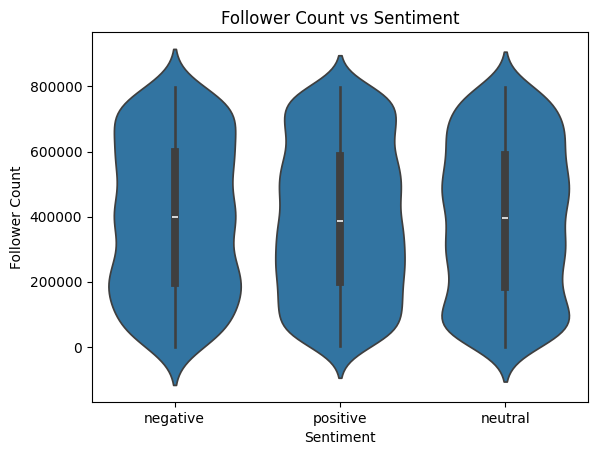

In [84]:
sns.violinplot(data=df, x='sentiment', y='follower_count')
plt.xlabel('Sentiment')
plt.ylabel('Follower Count')
plt.title('Follower Count vs Sentiment')
plt.show()

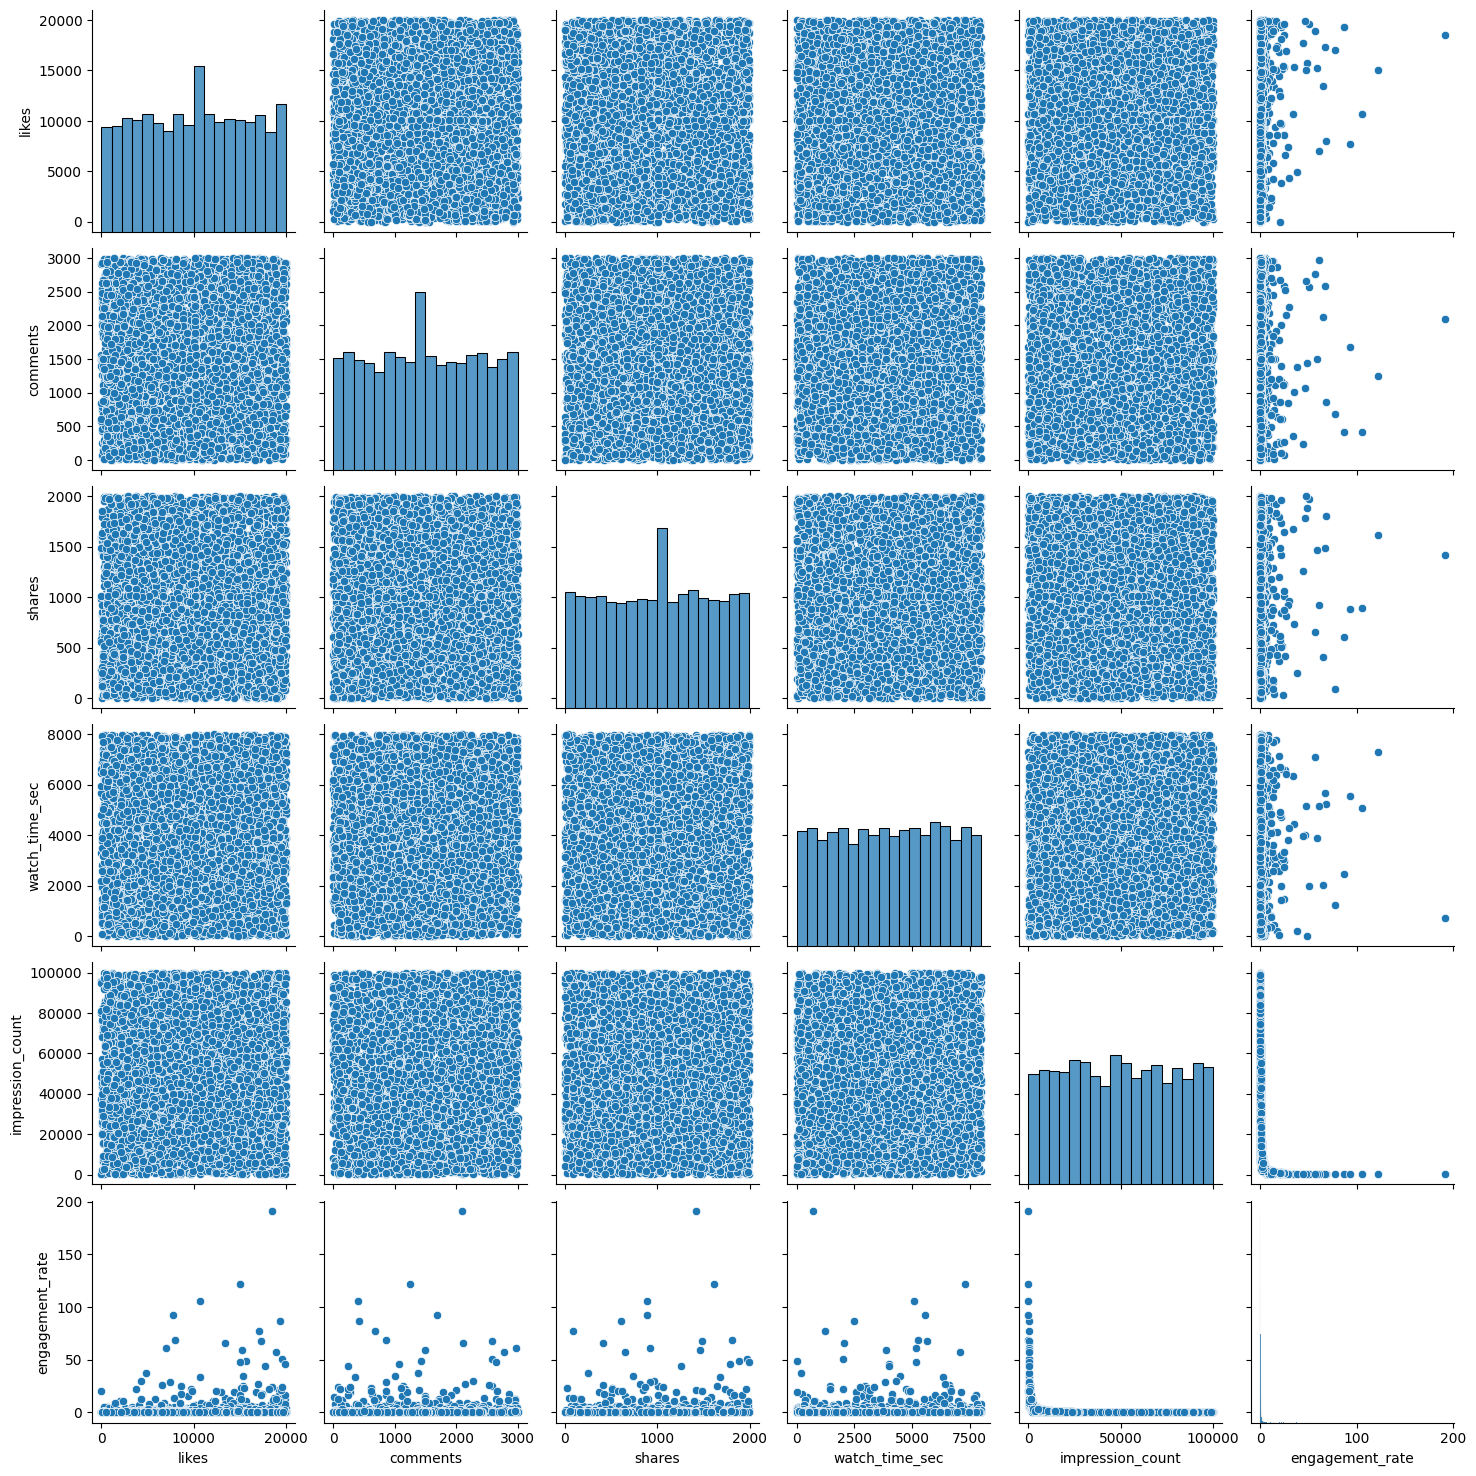

In [85]:
numeric_features =
 ['likes',
    'comments',
    'shares',
    'watch_time_sec',
    'impression_count',
    'engagement_rate']

sns.pairplot(df[numeric_features])

plt.show()

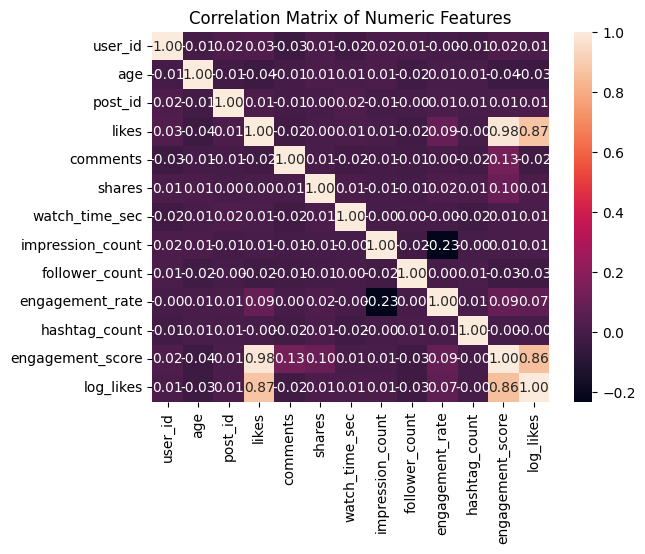

In [86]:
correlation_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 85.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 86.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 86.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 87.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.13/dist-packages/seaborn/categorical.py:3399: UserWarning: 88.5% of the points cannot be plac

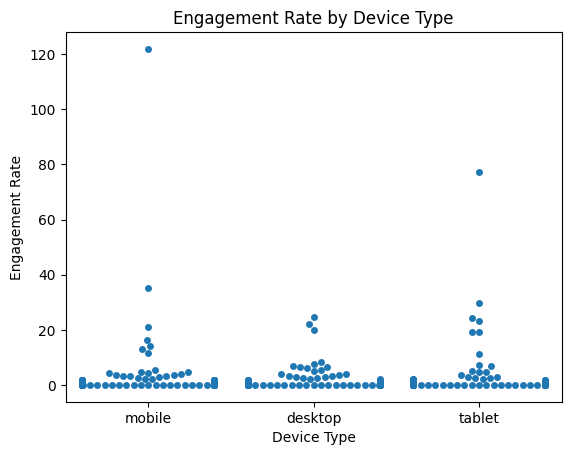

In [89]:
sample_df = df.sample(1000, random_state=42)
sns.swarmplot(data=sample_df, x='device_type', y='engagement_rate')
plt.xlabel('Device Type')
plt.ylabel('Engagement Rate')
plt.title('Engagement Rate by Device Type')
plt.show()

In [97]:
category_engagement = df.groupby('post_category', as_index=False)['engagement_rate'].mean()
fig = px.line(category_engagement,
    x='post_category',
    y='engagement_rate',
    markers=True,
    title='Average Engagement Rate by Post Category')
fig.show()

In [101]:
post_type_engagement = df.groupby('post_type')['engagement_rate'].mean().sort_values(ascending=False)

post_type_engagement

,engagement_rate
post_type,
video,1.122365
text,1.064549
image,0.895646
reel,0.783047


In [100]:
category_engagement = df.groupby('post_category')['engagement_rate'].mean().sort_values(ascending=False)

category_engagement

,engagement_rate
post_category,
food,1.358628
tech,1.160475
lifestyle,1.091019
music,0.888803
fitness,0.865628
education,0.844222
fashion,0.807109
travel,0.702223


In [102]:
country_engagement = df.groupby('country')['engagement_rate'].mean().sort_values(ascending=False)

country_engagement

,engagement_rate
country,
brazil,1.540704
australia,1.324339
france,1.146402
uae,1.112352
canada,0.916659
uk,0.850966
japan,0.769623
germany,0.759000
india,0.655005


In [104]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 25, 35, 45, 55, 65, 100],
    labels=['Under 18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

In [106]:
age_engagement = df.groupby('age_group',observed=False)['engagement_rate'].mean()

age_engagement

,engagement_rate
age_group,
Under 18,0.867038
18-25,1.059536
26-35,0.865316
36-45,0.860741
46-55,1.414058
56-65,0.709213
65+,NaN


In [107]:
verified_engagement = df.groupby('is_verified')['engagement_rate'].mean()

verified_engagement

,engagement_rate
is_verified,
False,0.954744
True,1.054250


In [108]:
df['post_hour'] = df['posted_at'].dt.hour
hourly_impressions = df.groupby('post_hour')['impression_count'].mean().sort_values(ascending=False)

hourly_impressions

,impression_count
post_hour,
0,50013.7328


In [109]:
sentiment_engagement = df.groupby('sentiment')['engagement_rate'].mean().sort_values(ascending=False)

sentiment_engagement

,engagement_rate
sentiment,
negative,1.038486
neutral,0.991170
positive,0.919744


In [110]:
negative_neutral = df[df['sentiment'].isin(['negative', 'neutral'])]
negative_neutral.groupby('sentiment')[['likes', 'comments', 'shares', 'engagement_rate']].mean()
negative_neutral['sentiment'].value_counts()

,count
sentiment,
neutral,1527
negative,960
